# 多頻道 Shorts 分析模板（template_multi）

適用情境：類別有 3+ 個頻道（如運動、時事、介紹食物、餐廳推廣）。
核心檢定：ANOVA（F_oneway）；OLS 含 C(channel_title) dummy。
title_length 切點改用 qcut 三分位數（避免某類別全部都 <15 字導致空組）。

## 0. 參數

In [1]:
# === 參數區 ===========================================================
# 改類別只要改這三行；下方所有 cell 都引用這些變數
CSV_TIMESTAMP = "20260527-065126"      # 改這裡切換不同類別的資料
TARGET_CHANNELS = None                  # None = 全部；或填 list 過濾特定頻道
CATEGORY_NAME = "介紹食物"               # 用於圖表標題、檔名
# ====================================================================

## 1. 匯入函式庫

In [2]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文字體（macOS 預設沒有 Microsoft 系列，使用 sans-serif 後備）
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Microsoft JhengHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style="whitegrid")

# 將 _templates/ 加入 sys.path 以便 import content_labeling
TPL_DIR = Path('../../analysis/_templates').resolve()
if str(TPL_DIR) not in sys.path:
    sys.path.insert(0, str(TPL_DIR))

print("✓ 函式庫載入完成")


✓ 函式庫載入完成


## 2. 載入 CSV

In [3]:
# 載入資料（路徑從 analysis/<cat>/ 回退兩層到 final project/）
df = pd.read_csv(f'../../data/processed/channel_videos_{CSV_TIMESTAMP}.csv', encoding='utf-8')
df_channels = pd.read_csv(f'../../data/processed/channels_{CSV_TIMESTAMP}.csv', encoding='utf-8')

if TARGET_CHANNELS is not None:
    df = df[df['channel_title'].isin(TARGET_CHANNELS)].copy()

print(f"✓ 資料載入：{len(df)} 列影片 / {len(df_channels)} 列頻道")
print(f"頻道：{df['channel_title'].unique().tolist()}")


✓ 資料載入：1227 列影片 / 7 列頻道
頻道：['E ating', '智明 Jimmypsd', 'This is Ken', '貓跪妃', '吃貨豪豪HowHowEat', '冬冬🌸生活美食日記💓', 'うまぐるめ【Japanese Food】']


## 3. 檢視資料結構

In [4]:
print(df.dtypes)
print()
print('頻道列表：', df['channel_title'].unique())
print()
print(df.head())


video_id                str
title                   str
description             str
channel_id              str
channel_title           str
published_at            str
category_id           int64
tags                    str
default_language        str
duration_iso            str
duration_sec          int64
definition              str
caption                bool
view_count            int64
like_count          float64
comment_count       float64
favorite_count        int64
topic_categories        str
fetched_at              str
dtype: object

頻道列表： <StringArray>
[             'E ating',          '智明 Jimmypsd',          'This is Ken',
                  '貓跪妃',        '吃貨豪豪HowHowEat',           '冬冬🌸生活美食日記💓',
 'うまぐるめ【Japanese Food】']
Length: 7, dtype: str

      video_id                                              title description  \
0  _Vhm6kQnOu4  台中200元吃到飽🫪#吃到飽 #台中 #台中美食 #西屯美食 #西屯區 #台中吃到飽 #台中...         NaN   
1  H5d_GOWeP_A       台中不一樣丼飯❤️#丼飯 #台中美食 #台中 #台中餐廳 #台中必吃 #南屯美食 #南屯         NaN

## 4. 資料清理與前處理

In [5]:
# 資料清理 + 派生欄位
df_clean = df.copy()
df_clean['published_at'] = pd.to_datetime(df_clean['published_at'])
df_clean['fetched_at'] = pd.to_datetime(df_clean['fetched_at'])

# 標題長度（混合 CJK + 英文之視覺字符數）
df_clean['title_length'] = df_clean['title'].fillna('').apply(len)

# CJK / EN 分開計，跨類別比較時較公平
def count_cjk(s):
    return sum(1 for c in str(s) if '一' <= c <= '鿿')

def count_en_words(s):
    import re
    return len(re.findall(r'[A-Za-z]+', str(s)))

df_clean['title_length_cjk'] = df_clean['title'].fillna('').apply(count_cjk)
df_clean['title_length_en'] = df_clean['title'].fillna('').apply(count_en_words)

# tag_count: 用 flatten_video 的 '|' 串接，注意 NaN
df_clean['tag_count'] = df_clean['tags'].fillna('').apply(lambda s: 0 if not s else len(s.split('|')))

# Shorts 判定（沿用 Reg/02、Reg/03 的 180 秒閾值）
df_shorts = df_clean[df_clean['duration_sec'] <= 180].copy()

print(f"原始：{len(df_clean)}  Shorts (≤180s)：{len(df_shorts)}")
print(f"  每頻道 Shorts 篇數：")
print(df_shorts['channel_title'].value_counts())


原始：1227  Shorts (≤180s)：965
  每頻道 Shorts 篇數：
channel_title
冬冬🌸生活美食日記💓              200
うまぐるめ【Japanese Food】    200
This is Ken             194
智明 Jimmypsd             165
貓跪妃                     109
E ating                  62
吃貨豪豪HowHowEat            35
Name: count, dtype: int64


## 4.5 內容貼標（Layer 1-3）

In [6]:
# === §4.5 內容貼標（Layer 1-3） ============================
# 此 cell 由 content_labeling.py 注入
import content_labeling as cl

df_with_topics, topic_counts = cl.explode_topic_categories(df_shorts)
df_lab = cl.apply_keyword_labels(df_with_topics, text_cols=("title", "tags"))
buckets = cl.load_keyword_dict()
label_cols = [f"has_{b}" for b in buckets]

print("Layer 1 — topic 全體計數 (Top 15)：")
print(topic_counts.head(15))
print()

topic_dist = cl.topic_distribution_by_channel(df_with_topics)
print("Layer 1 — 頻道 × topic 比例：")
print(topic_dist)
print()

print("Layer 2 — 規則式關鍵字命中率（按頻道）：")
print(df_lab.groupby('channel_title')[label_cols].mean().round(3))
print()

try:
    tfidf = cl.tfidf_top_keywords_by_channel(df_lab, n=15)
    print("Layer 3 — TF-IDF Top 15 keywords / channel：")
    for ch, kws in tfidf.items():
        print(f"\n{ch}:")
        for kw, sc in kws:
            print(f"  {kw:20s}  {sc:.4f}")
except RuntimeError as e:
    print(f"Layer 3 跳過：{e}")


Building prefix dict from the default dictionary ...


Loading model from cache /var/folders/wy/8m1lyrld379571szqbz_htvw0000gn/T/jieba.cache


Layer 1 — topic 全體計數 (Top 15)：
Lifestyle_(sociology)    948
Food                     881
Tourism                   94
Hobby                     10
Pet                        7
Entertainment              6
Health                     5
Music                      2
Technology                 2
Video_game_culture         2
Business                   1
Vehicle                    1
Humour                     1
dtype: int64

Layer 1 — 頻道 × topic 比例：
                          Food  Lifestyle_(sociology)   Tourism    Health  \
E ating               0.967742               0.967742  0.016129  0.000000   
This is Ken           0.773196               0.974227  0.329897  0.010309   
うまぐるめ【Japanese Food】  1.000000               1.000000  0.000000  0.000000   
冬冬🌸生活美食日記💓            0.895000               0.980000  0.020000  0.005000   
吃貨豪豪HowHowEat         0.857143               0.942857  0.028571  0.028571   
智明 Jimmypsd           0.945455               0.987879  0.145455  0.006061   
貓跪妃           

Loading model cost 0.217 seconds.


Prefix dict has been built successfully.


Layer 3 — TF-IDF Top 15 keywords / channel：

E ating:
  台中                    0.6847
  潤餅                    0.1580
  豆花                    0.1580
  飲料                    0.1312
  豆腐                    0.1121
  早餐                    0.1121
  草莓                    0.1121
  冰沙                    0.1053
  魚燒                    0.1053
  一碗                    0.0874
  芋泥                    0.0874
  開幕                    0.0747
  真的                    0.0747
  唯一                    0.0747
  30                    0.0747

This is Ken:
  東京                    0.2865
  日本                    0.2407
  好吃                    0.2309
  in                    0.2046
  就是                    0.1853
  京都                    0.1452
  台灣                    0.1320
  機場                    0.1302
  真的                    0.1188
  美食                    0.1146
  甜甜                    0.1116
  自己                    0.1081
  涉谷                    0.0930
  美國                    0.0930
  但是                    0.0930

う

## 5. 描述性統計

In [7]:
# 描述性統計
metrics = ['view_count', 'like_count', 'comment_count', 'duration_sec',
           'title_length', 'tag_count']
print("Shorts 主要指標統計：")
for m in metrics:
    if m in df_shorts.columns:
        d = df_shorts[m].dropna()
        if len(d) == 0:
            continue
        print(f"  {m:15s} mean={d.mean():>12,.1f}  median={d.median():>10,.1f}  std={d.std():>12,.1f}")

# 頻道級摘要
print("\n每頻道摘要：")
agg = df_shorts.groupby('channel_title').agg(
    n_shorts=('video_id', 'count'),
    mean_view=('view_count', 'mean'),
    median_view=('view_count', 'median'),
    mean_like=('like_count', 'mean'),
    mean_comment=('comment_count', 'mean'),
)
print(agg)


Shorts 主要指標統計：
  view_count      mean=   514,372.6  median= 120,935.0  std= 1,739,090.6
  like_count      mean=    12,556.5  median=   2,000.0  std=    36,595.5
  comment_count   mean=       116.9  median=      30.0  std=       243.9
  duration_sec    mean=        45.9  median=      48.0  std=        20.4
  title_length    mean=        36.6  median=      34.0  std=        21.2
  tag_count       mean=         0.0  median=       0.0  std=         0.2

每頻道摘要：
                      n_shorts     mean_view  median_view     mean_like  \
channel_title                                                             
E ating                     62  4.046456e+04       5197.5    349.451613   
This is Ken                194  5.129163e+05     172559.0  14451.907216   
うまぐるめ【Japanese Food】       200  9.786409e+05     254141.5  20883.970000   
冬冬🌸生活美食日記💓                 200  7.118785e+04      22162.5    569.700000   
吃貨豪豪HowHowEat               35  3.566371e+05     289561.0   7951.657143   
智明 Jimmypsd   

## 6. 發佈時間趨勢

In [8]:
# 發佈時間特徵
df_shorts['pub_date'] = df_shorts['published_at'].dt.date
df_shorts['pub_hour'] = df_shorts['published_at'].dt.hour
df_shorts['pub_day_of_week'] = df_shorts['published_at'].dt.day_name()
df_shorts['pub_hour_band'] = pd.cut(df_shorts['pub_hour'], bins=[-1,5,11,17,21,24],
                                     labels=['深夜','早','中','下','晚'])

# 按小時
print("按發佈時段平均觀看數：")
print(df_shorts.groupby('pub_hour_band', observed=False)['view_count'].mean().round(0))


按發佈時段平均觀看數：
pub_hour_band
深夜    372835.0
早     673480.0
中     479087.0
下     333551.0
晚     340795.0
Name: view_count, dtype: float64


## 7. 相關性分析

In [9]:
# 相關性分析
analysis_cols = ['view_count', 'like_count', 'comment_count', 'duration_sec',
                 'title_length', 'tag_count']
corr = df_shorts[analysis_cols].corr()
print("相關係數矩陣：")
print(corr.round(3))

print("\n與 view_count 的相關性顯著性檢定（Pearson）：")
for col in ['like_count', 'comment_count', 'duration_sec', 'title_length', 'tag_count']:
    d = df_shorts[[col, 'view_count']].dropna()
    if len(d) > 2:
        r, p = stats.pearsonr(d[col], d['view_count'])
        sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
        print(f"  {col:15s} r={r:+.4f}  p={p:.4e} {sig}")


相關係數矩陣：
               view_count  like_count  comment_count  duration_sec  \
view_count          1.000       0.939          0.840         0.141   
like_count          0.939       1.000          0.834         0.178   
comment_count       0.840       0.834          1.000         0.233   
duration_sec        0.141       0.178          0.233         1.000   
title_length        0.106       0.117          0.099         0.048   
tag_count          -0.015      -0.018         -0.022         0.057   

               title_length  tag_count  
view_count            0.106     -0.015  
like_count            0.117     -0.018  
comment_count         0.099     -0.022  
duration_sec          0.048      0.057  
title_length          1.000     -0.035  
tag_count            -0.035      1.000  

與 view_count 的相關性顯著性檢定（Pearson）：
  like_count      r=+0.9388  p=0.0000e+00 ***
  comment_count   r=+0.8405  p=3.1835e-258 ***
  duration_sec    r=+0.1412  p=1.0694e-05 ***
  title_length    r=+0.1060  p=9.7946e-04

## 7.5 內容標籤與觀看數的關係

In [10]:
# === §7.5 內容標籤與觀看數的關係 ==========================
# 此 cell 由 content_labeling.py 注入：卡方 + logistic
from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf

# 高觀看 = top quartile（每頻道內或整體）
view_q3 = df_lab['view_count'].quantile(0.75)
df_lab['top_quartile'] = (df_lab['view_count'] >= view_q3).astype(int)

print(f"top_quartile 門檻：view_count >= {view_q3:,.0f}")
print()

print("每個 label vs 高觀看 卡方檢定：")
for col in label_cols:
    if df_lab[col].sum() < 5 or df_lab[col].sum() > len(df_lab) - 5:
        print(f"  {col:25s} (樣本太集中, 跳過)")
        continue
    tab = pd.crosstab(df_lab[col], df_lab['top_quartile'])
    chi2, p, _, _ = chi2_contingency(tab)
    sig = "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "ns"
    print(f"  {col:25s} chi2={chi2:6.2f}  p={p:.4e} {sig}")

# Logistic：P(top_quartile) ~ has_*
formula = "top_quartile ~ " + " + ".join(label_cols)
try:
    model = smf.logit(formula=formula, data=df_lab).fit(disp=False)
    print("\nLogistic 迴歸：")
    print(model.summary())
except Exception as e:
    print(f"\nLogistic 跳過：{e}")


top_quartile 門檻：view_count >= 492,169

每個 label vs 高觀看 卡方檢定：
  has_教學教育                  chi2=  0.00  p=1.0000e+00 ns
  has_挑戰對決                  chi2=  0.34  p=5.5864e-01 ns
  has_搞笑迷因                  (樣本太集中, 跳過)
  has_開箱評測                  (樣本太集中, 跳過)
  has_互動誘導                  (樣本太集中, 跳過)
  has_情緒詞                   chi2=  1.24  p=2.6453e-01 ns
  has_品牌推廣                  chi2=  0.05  p=8.2311e-01 ns
  has_食物                    chi2= 23.12  p=1.5216e-06 ***
  has_運動                    (樣本太集中, 跳過)
  has_問句                    chi2=176.44  p=2.9069e-40 ***

Logistic 迴歸：
                           Logit Regression Results                           
Dep. Variable:           top_quartile   No. Observations:                  965
Model:                          Logit   Df Residuals:                      954
Method:                           MLE   Df Model:                           10
Date:                Wed, 27 May 2026   Pseudo R-squ.:                  0.1627
Time:                     

/Users/waynliu/Documents/NTU/台大/大二下/統計一下/final project/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 8. Top 10 視覺化

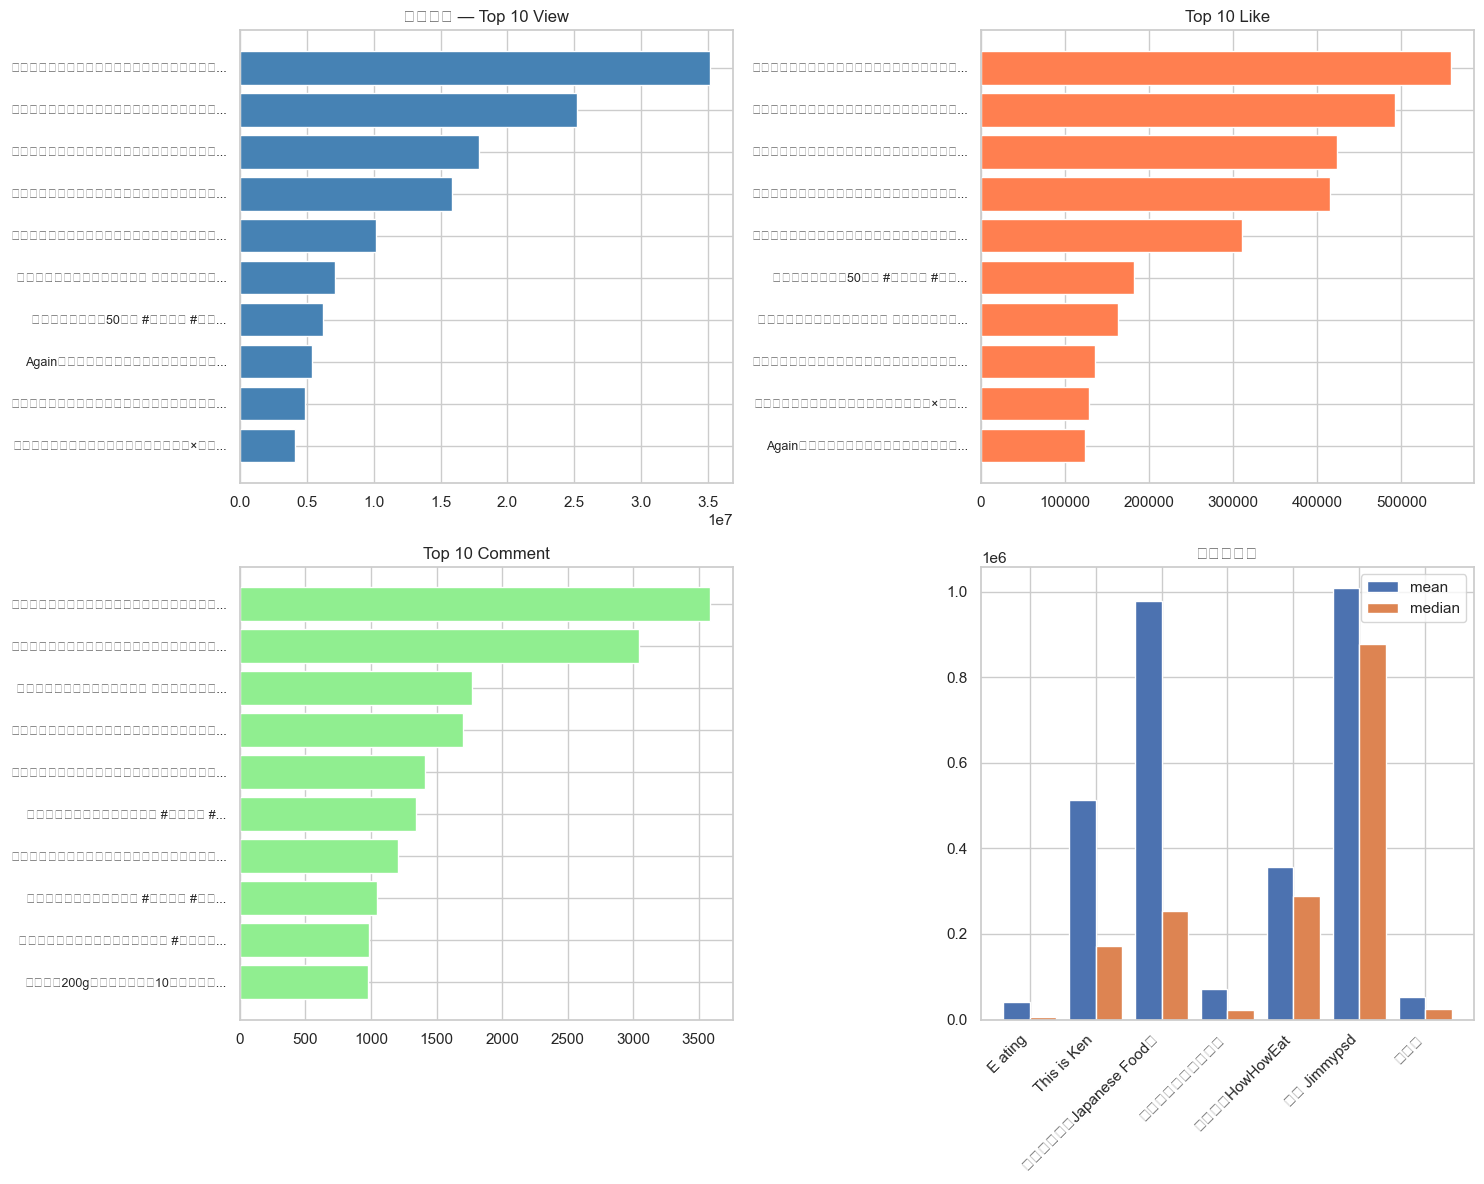

In [11]:
# Top 10 視覺化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

t10v = df_shorts.nlargest(10, 'view_count')
axes[0,0].barh(range(len(t10v)), t10v['view_count'].values, color='steelblue')
axes[0,0].set_yticks(range(len(t10v)))
axes[0,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10v['title']], fontsize=9)
axes[0,0].set_title(f'{CATEGORY_NAME} — Top 10 View'); axes[0,0].invert_yaxis()

t10l = df_shorts.nlargest(10, 'like_count')
axes[0,1].barh(range(len(t10l)), t10l['like_count'].values, color='coral')
axes[0,1].set_yticks(range(len(t10l)))
axes[0,1].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10l['title']], fontsize=9)
axes[0,1].set_title('Top 10 Like'); axes[0,1].invert_yaxis()

t10c = df_shorts.nlargest(10, 'comment_count')
axes[1,0].barh(range(len(t10c)), t10c['comment_count'].values, color='lightgreen')
axes[1,0].set_yticks(range(len(t10c)))
axes[1,0].set_yticklabels([f"{t[:22]}..." if len(str(t))>22 else str(t) for t in t10c['title']], fontsize=9)
axes[1,0].set_title('Top 10 Comment'); axes[1,0].invert_yaxis()

ch_summary = df_shorts.groupby('channel_title')['view_count'].agg(['mean','median']).reset_index()
x = range(len(ch_summary))
axes[1,1].bar([i-0.2 for i in x], ch_summary['mean'], 0.4, label='mean')
axes[1,1].bar([i+0.2 for i in x], ch_summary['median'], 0.4, label='median')
axes[1,1].set_xticks(list(x))
axes[1,1].set_xticklabels(ch_summary['channel_title'], rotation=45, ha='right')
axes[1,1].set_title('頻道觀看數'); axes[1,1].legend()

plt.tight_layout(); plt.show()


## 9. ANOVA（多因子）

In [12]:
from scipy.stats import f_oneway

# title_length 用 qcut 三等分位數（動態），避免空組
df_shorts['title_length_group'] = pd.qcut(df_shorts['title_length'], q=3,
                                           labels=['短','中','長'], duplicates='drop')

# tag_count: 0 / 1-3 / 4+
df_shorts['tag_count_group'] = pd.cut(df_shorts['tag_count'], bins=[-1,0,3,1000],
                                      labels=['無標籤','1-3','4+'])

print("=" * 70)
print("【RQ1】標題長度 vs 觀看數")
for name, g in df_shorts.groupby('title_length_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('title_length_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【RQ3】標籤數量 vs 觀看數")
for name, g in df_shorts.groupby('tag_count_group', observed=False):
    v = g['view_count'].dropna()
    if len(v): print(f"  {name}: n={len(v)}  mean={v.mean():>12,.0f}  median={v.median():>10,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('tag_count_group', observed=False) if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")

print("\n" + "=" * 70)
print("【控制】頻道 vs 觀看數")
for ch, g in df_shorts.groupby('channel_title'):
    v = g['view_count'].dropna()
    print(f"  {ch}: n={len(v)}  mean={v.mean():>12,.0f}")
grps = [g['view_count'].dropna().values for _, g in df_shorts.groupby('channel_title') if len(g)>0]
if len(grps) >= 2:
    f, p = f_oneway(*grps)
    print(f"ANOVA F={f:.4f}  p={p:.4e}")


【RQ1】標題長度 vs 觀看數
  短: n=328  mean=     222,942  median=    54,654
  中: n=320  mean=     683,970  median=   291,144
  長: n=317  mean=     644,713  median=   117,172
ANOVA F=7.1063  p=8.6369e-04

【RQ3】標籤數量 vs 觀看數
  無標籤: n=962  mean=     515,889  median=   121,983
  1-3: n=3  mean=      28,143  median=    31,646
ANOVA F=0.2351  p=6.2791e-01

【控制】頻道 vs 觀看數
  E ating: n=62  mean=      40,465
  This is Ken: n=194  mean=     512,916
  うまぐるめ【Japanese Food】: n=200  mean=     978,641
  冬冬🌸生活美食日記💓: n=200  mean=      71,188
  吃貨豪豪HowHowEat: n=35  mean=     356,637
  智明 Jimmypsd: n=165  mean=   1,007,727
  貓跪妃: n=109  mean=      51,670
ANOVA F=9.3129  p=6.0657e-10


## 10. 迴歸（多模型）

In [13]:
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_reg = df_shorts[['view_count','duration_sec','title_length','tag_count','channel_title']].dropna()
print(f"迴歸樣本數：{len(df_reg)}")

if len(df_reg) >= 10:
    scaler = StandardScaler()
    feats = ['duration_sec','title_length','tag_count']
    dfs = df_reg.copy()
    dfs[feats] = scaler.fit_transform(df_reg[feats])

    m1 = smf.ols('view_count ~ duration_sec + title_length + tag_count', data=dfs).fit()
    m2 = smf.ols('view_count ~ duration_sec + title_length + tag_count + C(channel_title)', data=dfs).fit()
    print("Model 1：")
    print(m1.summary())
    print("\nModel 2（含 channel dummy）：")
    print(m2.summary())
    print(f"\nM1 R²={m1.rsquared:.4f}  Adj R²={m1.rsquared_adj:.4f}")
    print(f"M2 R²={m2.rsquared:.4f}  Adj R²={m2.rsquared_adj:.4f}")

    X = m1.model.exog
    names = m1.model.exog_names
    vif = pd.DataFrame({"Variable": names[1:],
                        "VIF": [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]})
    print("\nVIF：")
    print(vif.to_string(index=False))
else:
    print("樣本太少，跳過迴歸")


迴歸樣本數：965


Model 1：
                            OLS Regression Results                            
Dep. Variable:             view_count   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     9.970
Date:                Wed, 27 May 2026   Prob (F-statistic):           1.78e-06
Time:                        14:56:24   Log-Likelihood:                -15220.
No. Observations:                 965   AIC:                         3.045e+04
Df Residuals:                     961   BIC:                         3.047e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     5.144e+05   5.52e+04    

## 11. ANOVA 視覺化

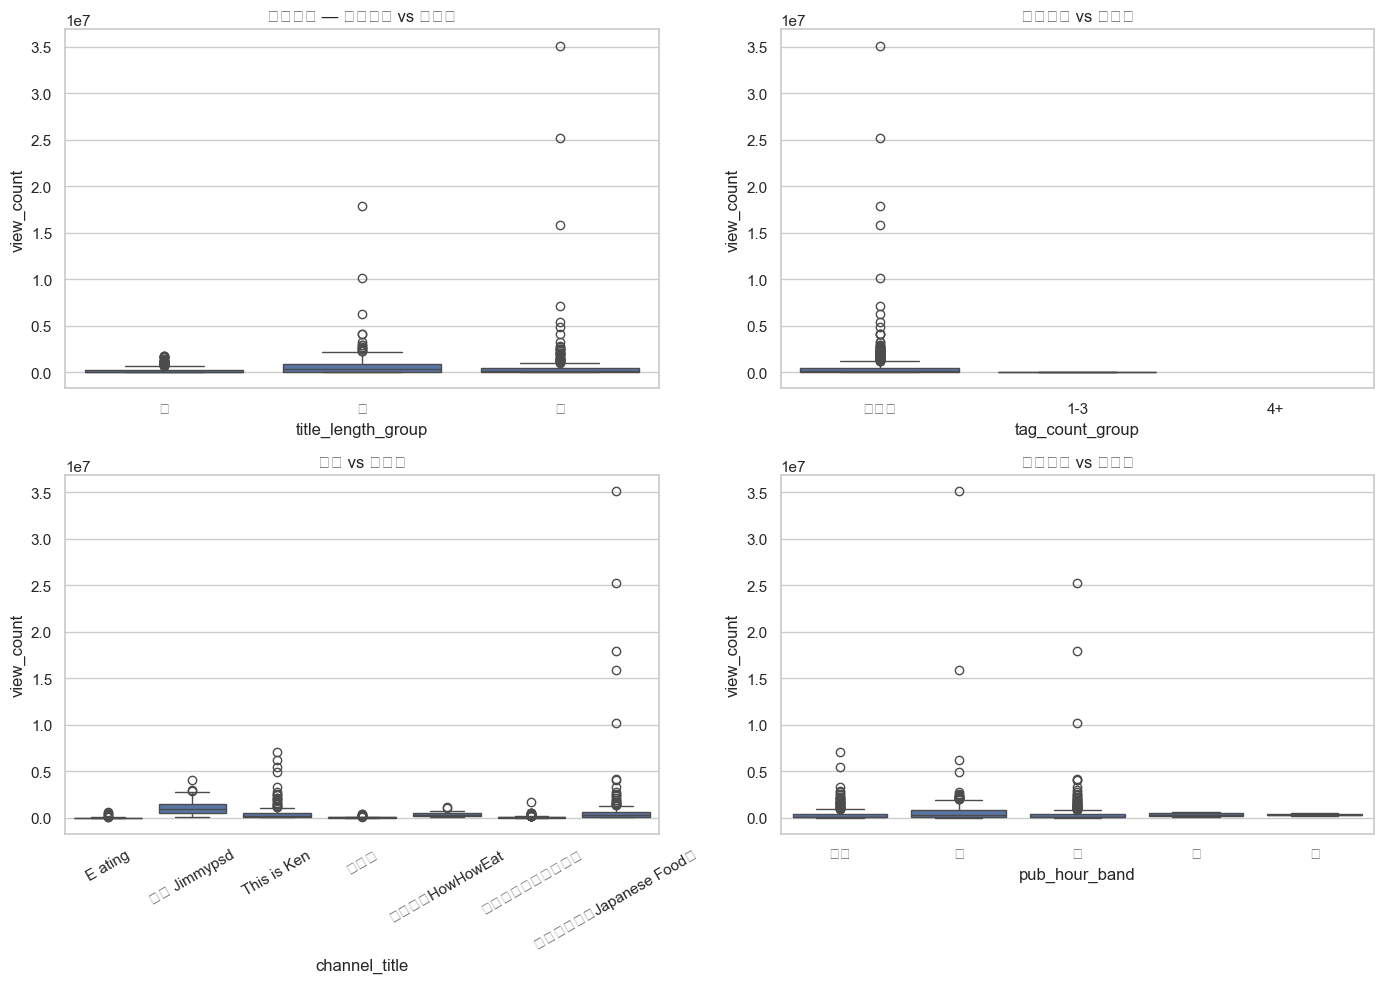

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(data=df_shorts, x='title_length_group', y='view_count', ax=axes[0,0])
axes[0,0].set_title(f'{CATEGORY_NAME} — 標題長度 vs 觀看數')
sns.boxplot(data=df_shorts, x='tag_count_group', y='view_count', ax=axes[0,1])
axes[0,1].set_title('標籤數量 vs 觀看數')
sns.boxplot(data=df_shorts, x='channel_title', y='view_count', ax=axes[1,0])
axes[1,0].set_title('頻道 vs 觀看數'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df_shorts, x='pub_hour_band', y='view_count', ax=axes[1,1])
axes[1,1].set_title('發佈時段 vs 觀看數')
plt.tight_layout(); plt.show()


## 12. 結論

（依分析結果手動撰寫）